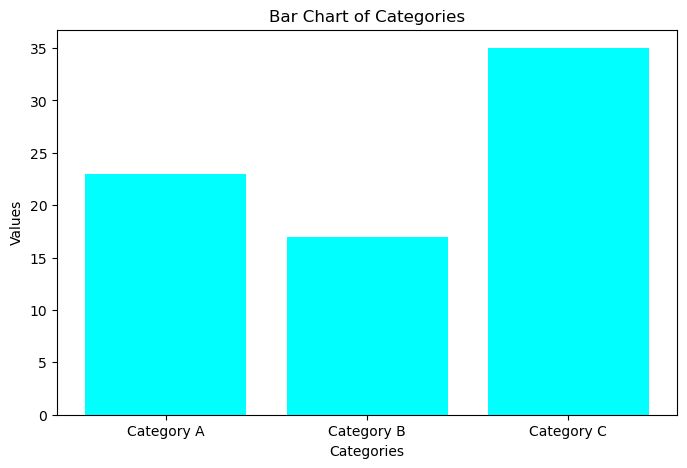

In [1]:
import matplotlib.pyplot as plt
categories = ['Category A', 'Category B', 'Category C']
values = [23, 17, 35]

plt.figure(figsize=(8,5))
plt.bar(categories, values, color='cyan')
plt.xlabel('Categories')
plt.ylabel('Values')
plt.title('Bar Chart of Categories')
plt.show()

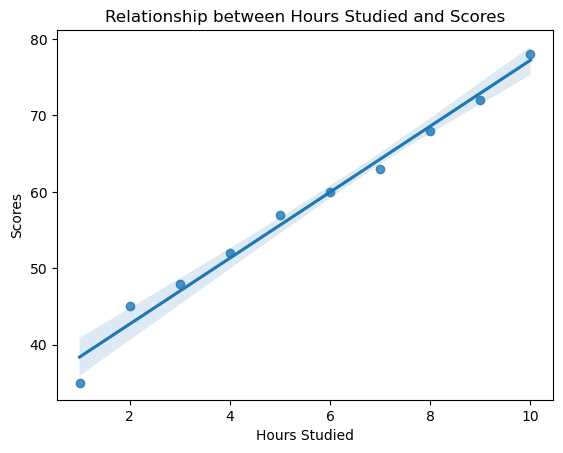

In [1]:
import seaborn as sns 
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Hours Studied' : [1,2,3,4,5,6,7,8,9,10],
    'Scores' : [35,45,48,52,57,60,63,68,72,78]
}
df = pd.DataFrame(data)

sns.regplot(x='Hours Studied', y= 'Scores', data=df)
plt.title('Relationship between Hours Studied and Scores')
plt.show()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

file_path = "Titanic-Dataset.csv"

df = pd.read_csv(file_path)

print("Data awal")
print(import_file.head())


Data awal
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

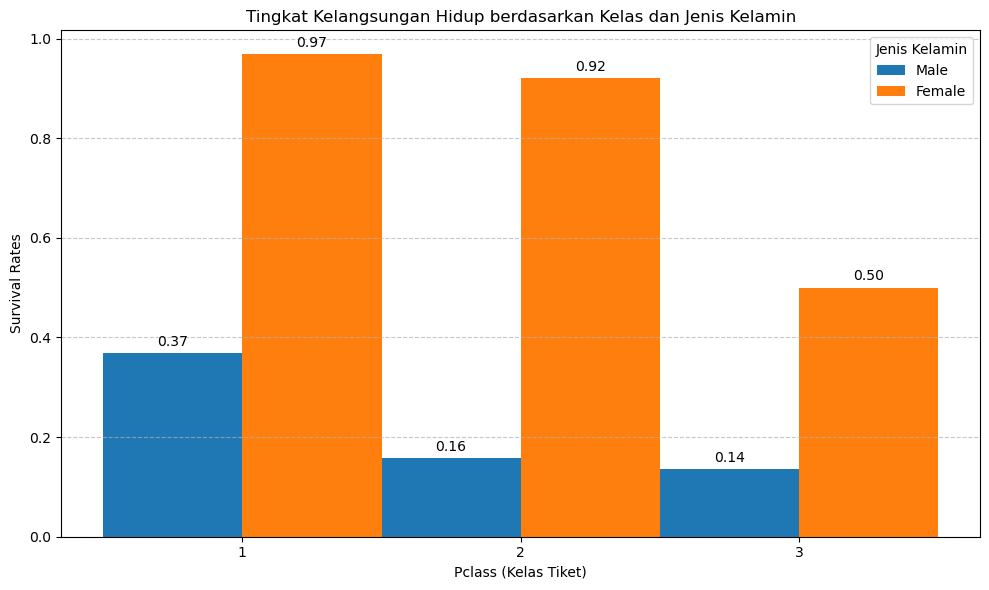

In [18]:
survival_rate = df.groupby(['Pclass', 'Sex'] )['Survived'].mean().unstack()

labels = survival_rate.index.astype(str)
male_rate = survival_rate['male']
female_rate = survival_rate['female']

x = np.arange(len(labels))
width = 0.5

fig, ax = plt.subplots(figsize=(10,6))
left = ax.bar(x - width/2, male_rate, width, label='Male', color= '#1f77b4')
right = ax.bar(x + width/2, female_rate, width, label='Female', color= '#ff7f0e')

ax.set_ylabel("Survival Rates")
ax.set_xlabel('Pclass (Kelas Tiket)')
ax.set_title('Tingkat Kelangsungan Hidup berdasarkan Kelas dan Jenis Kelamin')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(title='Jenis Kelamin')

ax.bar_label(left, padding=3, fmt='%.2f')
ax.bar_label(right, padding=3, fmt='%.2f')


ax.yaxis.grid(True, linestyle='--', alpha=0.7)

fig.tight_layout()

plt.show()

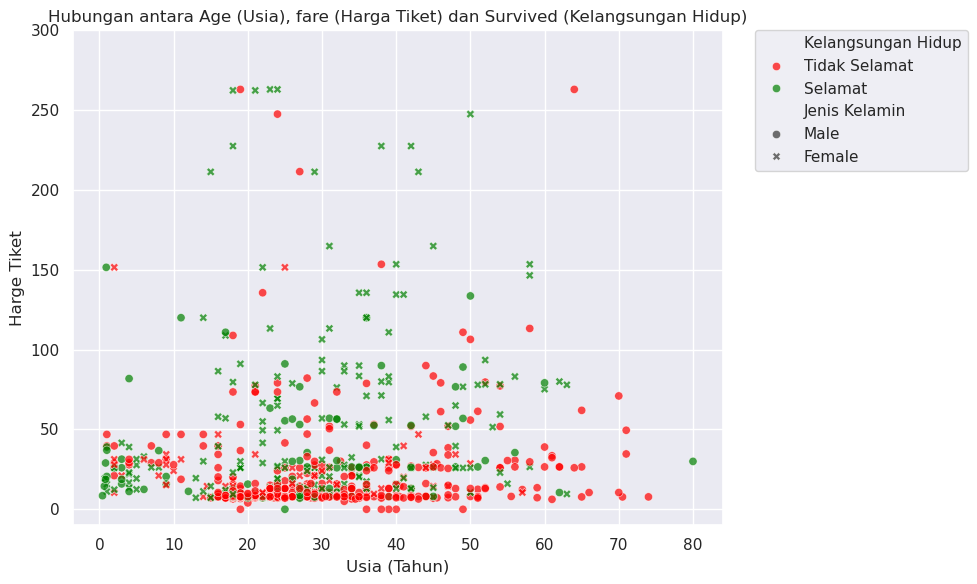

In [20]:
sns.set_theme(style= 'darkgrid')
plt.figure(figsize=(10,6))

scatter_plot = sns.scatterplot(
    data = df, x = 'Age', y = 'Fare', hue = 'Survived',
    style = 'Sex', palette = {0: 'red', 1: 'green'}, alpha = 0.7
)

plt.title("Hubungan antara Age (Usia), fare (Harga Tiket) dan Survived (Kelangsungan Hidup)")
plt.xlabel("Usia (Tahun)")
plt.ylabel("Harge Tiket")

handles, labels = scatter_plot.get_legend_handles_labels()
try:
    sep_idx = labels.index('Sex')
except ValueError:
    sep_idx = len(labels)

new_labels = []
new_handles = []
new_labels.append('Kelangsungan Hidup')
new_handles.append(handles[0])
new_labels.extend(['Tidak Selamat', 'Selamat'])
new_handles.extend(handles[1:3])
new_labels.append('Jenis Kelamin')
new_handles.append(handles[sep_idx])
new_labels.extend(['Male', 'Female'])
new_handles.extend(handles[sep_idx+1:])

scatter_plot.legend(new_handles, new_labels, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

plt.ylim(-10, 300) 

plt.tight_layout()